# IMPORTING LIBRARIES AND DUMPING DATA FROM LOCATION TO MYSQL THROUGH PYTHON

In [149]:
#install mysql-connector-python
import pandas as pd
import mysql.connector
import os
import numpy as np 

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('order_items.csv', 'order_items'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments') ,
     ('products.csv', 'products')
    # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='pythonuser',
    password='mypassword',
    database='ecommerceProject'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = '/Users/ehtishamzahid/Documents/ecommerceProject'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing order_items.csv
NaN values before replacement:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value        

In [183]:
import pandas as pd
import mysql.connector
import os
import matplotlib.pyplot as plt
import seaborn as sns 

db=mysql.connector.connect(
    host='localhost',
    user='pythonuser',
    password='mypassword',
    database='ecommerceproject'

)
cur= db.cursor()

# Listing all unique cities where customers are located


In [92]:
#while cur.nextset():
 #   pass
query= """ select distinct(customer_city) from customers;
"""
cur.execute(query)
data= cur.fetchall()
df=pd.DataFrame(data,columns=['city'])
df

,city
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


# number of orders placed in 2017.

In [93]:
query= """ select count(order_approved_at) from orders where year(order_purchase_timestamp)= 2017; """
cur.execute(query)
data=cur.fetchall()
data

[(270174,)]

#  percentage of orders that were paid in installments.


In [94]:
query=""" SELECT  (sum(case 
when payment_installments >= 1 then 1
else 0 end)*100)/count(*) from payments;
"""
cur.execute(query)
data= cur.fetchall()
data

[(Decimal('99.9981'),)]

# number of customers from each state.


In [59]:
query = """select customer_state, count(customer_id) from customers group by customer_state;"""
cur.execute(query)
data=cur.fetchall()
data 
df3= pd.DataFrame(data,columns=['states',"cutomersinstate"])
df3

,states,cutomersinstate
0,SP,208730
1,SC,18185
2,MG,58175
3,PR,25225
4,RJ,64260
5,RS,27330
6,PA,4875
7,GO,10100
8,ES,10165
9,BA,16900


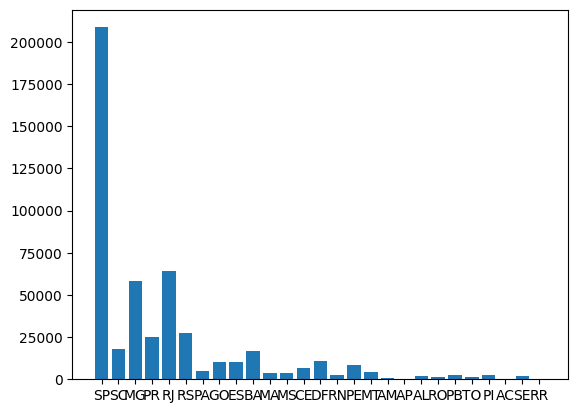

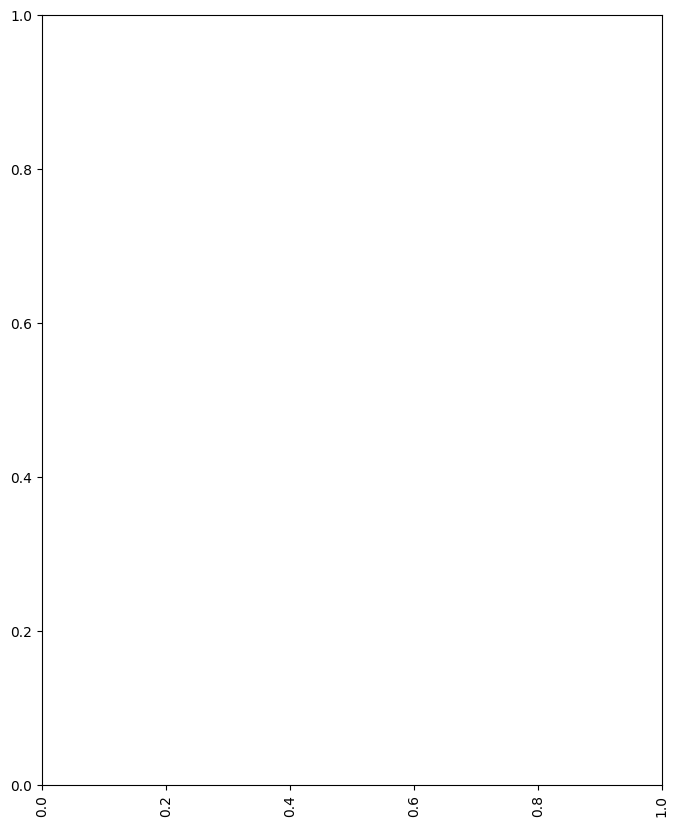

In [182]:
plt.bar(df3['states'],df3['cutomersinstate'],)
plt.figure(figsize=(8,10))
plt.xticks(rotation=90)
plt.xlabel="states"
plt.ylabel="customer size"



# number of orders per month in 2018.


In [111]:
while cur.nextset():
    pass
    
 
query="""select monthname(order_purchase_timestamp) as monthorders, count(order_id) from orders where year(order_purchase_timestamp) = 2018 group by monthorders;  """
cur.execute(query)
data=cur.fetchall()
data 
df4=pd.DataFrame(data,columns=["month","NoOfOrders"])
df4



,month,NoOfOrders
0,July,37752
1,August,39072
2,February,40368
3,June,37002
4,March,43266
5,January,43614
6,May,41238
7,April,41634
8,September,96
9,October,24


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

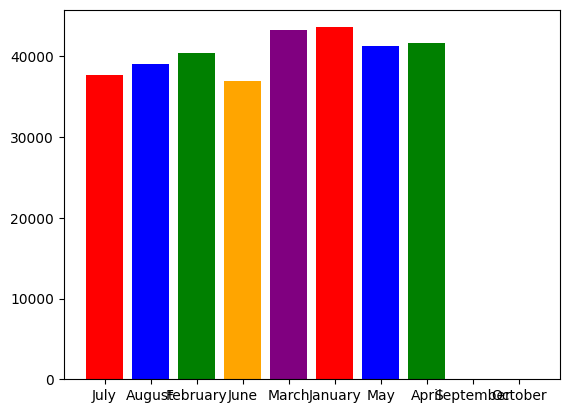

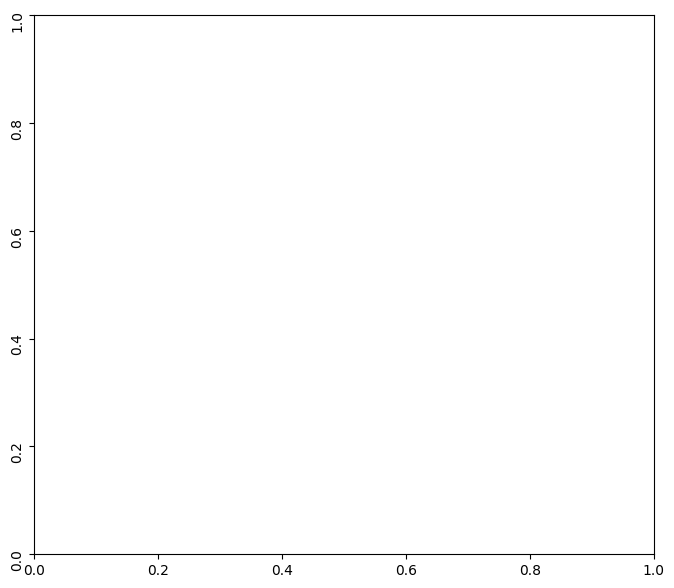

In [132]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
plt.bar(df4['month'],df4['NoOfOrders'],color=colors)
plt.figure(figsize=(8,7))
plt.yticks(rotation=90)


# Find the average number of products per order, grouped by customer city.


# percentage of total revenue contributed by each product category.

In [135]:
query="""select upper(products.product_category) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc"""
cur.execute(query)
data5=cur.fetchall()
data5

[('BED TABLE BATH', 192.56),
 ('HEALTH BEAUTY', 186.35),
 ('COMPUTER ACCESSORIES', 178.25),
 ('FURNITURE DECORATION', 160.81),
 ('WATCHES PRESENT', 160.7),
 ('SPORT LEISURE', 156.53),
 ('HOUSEWARES', 123.09),
 ('AUTOMOTIVE', 95.83),
 ('GARDEN TOOLS', 94.25),
 ('COOL STUFF', 87.67),
 ('FURNITURE OFFICE', 72.73),
 ('TOYS', 69.6),
 ('BABIES', 60.7),
 ('PERFUMERY', 56.98),
 ('TELEPHONY', 54.74),
 ('STATIONARY STORE', 35.69),
 ('PET SHOP', 35.0),
 ('PCS', 31.38),
 ('ELECTRONICS', 29.22),
 (None, 28.42),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 27.15),
 ('MUSICAL INSTRUMENTS', 26.21),
 ('ELECTROSTILE', 25.36),
 ('FASHION BAGS AND ACCESSORIES', 24.53),
 ('FIXED TELEPHONY', 23.28),
 ('GAMES CONSOLES', 21.98),
 ('BAGS ACCESSORIES', 21.04),
 ('CASA CONSTRUCAO', 15.36),
 ('ROOM FURNITURE', 15.31),
 ('ELECTRICES 2', 14.01),
 ('AGRO INDUSTRIA E COMERCIO', 13.35),
 ('HOME APPLIANCES', 10.74),
 ('CLIMATIZATION', 10.25),
 ('HOUSE COMFORT', 9.48),
 ('FURNITURE KITCHEN SERVICE AREA DINNER AND GARDEN', 8.39)

In [136]:
df5= pd.DataFrame(data5)

# correlation between product price and the number of times a product has been purchased.


In [147]:
while cur.nextset():
    pass
query= """  select products.product_id id, count(order_items.product_id), round(avg(order_items.price),2) price from products join 
	order_items on products.product_id=order_items.product_id group by products.product_id ;  """

cur.execute(query)
data6= cur.fetchall()
data6

[('310ae3c140ff94b03219ad0adc3c778f', 36, 145.95),
 ('8cab8abac59158715e0d70a36c807415', 36, 99.9),
 ('b50c950aba0dcead2c48032a690ce817', 72, 99.0),
 ('5ed9eaf534f6936b51d0b6c5e4d5c2e9', 378, 24.98),
 ('35537536ed2b4c561b4018bf3abf54e0', 234, 382.31),
 ('1f9799a175f50c9fa725984775cac5c5', 36, 59.9),
 ('fadc89c2a60ff96b18827644074dfd70', 180, 76.22),
 ('656e0eca68dcecf6a31b8ececfabe3e8', 2538, 88.49),
 ('53b36df67ebb7c41585e8d54d6772e08', 5814, 116.67),
 ('5e21d5cab5d33e770d8150a4ee6117db', 216, 49.0),
 ('d0fb1e667e989933a80444f93da833c0', 18, 37.9),
 ('c589625c8ccc7bfd2e8f1fb041e24c4a', 288, 110.32),
 ('601a360bd2a916ecef0e88de72a6531a', 2142, 127.39),
 ('2f763ba79d9cd987b2034aac7ceffe06', 18, 469.0),
 ('e10758160da97891c2fdcbc35f0f031d', 36, 56.0),
 ('83d199d296c44101c8c3b5c9c0cce9ea', 306, 72.34),
 ('31a2f42a87890f87d77daebdfabc182e', 756, 146.46),
 ('ce130b350f529a1d6288f927da7404ea', 72, 64.9),
 ('2083a6feb4bbb31f6abc92fc24e468c0', 468, 6.92),
 ('a963ea4d494221de09b70f1b4a70edbd', 

In [151]:
df6= pd.DataFrame(data6, columns=["products","price","purchased"])
np.corrcoef(x=df6["price"],y=df6["purchased"])


array([[ 1.        , -0.03213985],
       [-0.03213985,  1.        ]])

# Calculate the total revenue generated by each seller, and rank them by revenue.

In [153]:
query="""  select *, dense_rank() over(order by revenue desc) 
   from(
   select 
   payments.order_id seller, sum(payments.payment_value) revenue
from 
order_items join payments on order_items.order_id=payments.order_id  group by seller
) as a;"""
cur.execute(query)
data=cur.fetchall()
data
df7= pd.DataFrame(data)
df7

,0,1,2
0,03caa2c082116e1d31e67e9ae3700499,3.279379e+06,1
1,ab14fdcfbe524636d65ee38360e22ce8,1.357680e+06,2
2,1b15974a0141d54e36626dca3fdc731a,1.321440e+06,3
3,2cc9089445046817a7539d90805e6e5a,1.094677e+06,4
4,e8fa22c3673b1dd17ea315021b1f0f61,9.055800e+05,5
...,...,...,...
98660,38bcb524e1c38c2c1b60600a80fc8999,3.486000e+02,31463
98661,47d11383b93b217d96defbb2ef1a209b,3.468000e+02,31464
98662,37193e64eb9a46b7f3197762f242b20a,3.267000e+02,31465
98663,e8bbc1d69fee39eee4c72cb5c969e39d,3.021000e+02,31466


# Calculate the moving average of order values for each customer over their order history.

In [154]:
query=""" select *, avg(paymnt) over( order by opt rows between unbounded preceding  and current row)
from
(select orders.customer_id cust, orders.order_purchase_timestamp opt, payments.payment_value paymnt from payments join
orders on payments.order_id=orders.order_id ) as aa;"""
cur.execute(query)
data8=cur.fetchall()
data8
df8= pd.DataFrame(data8,columns=["customerId","timestamp","payment",""])
df8

,0,1,2,3
0,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.229996
1,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.229996
2,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.229996
3,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.229996
4,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.229996
...,...,...,...,...
3116575,a4b417188addbc05b26b72d5e44837a1,2018-10-17 17:30:18,89.71,154.100463
3116576,a4b417188addbc05b26b72d5e44837a1,2018-10-17 17:30:18,89.71,154.100442
3116577,a4b417188addbc05b26b72d5e44837a1,2018-10-17 17:30:18,89.71,154.100422
3116578,a4b417188addbc05b26b72d5e44837a1,2018-10-17 17:30:18,89.71,154.100401


# Calculate the cumulative sales per month for each year.


In [155]:
query=""" select *,sum(paym) over( order by years, months) from
(select year(orders.order_purchase_timestamp) years, month(orders.order_purchase_timestamp) months, 
sum(payments.payment_value) paym from orders join payments on orders.order_id=payments.order_id 
group by years, months) abb;"""
cur.execute(query)
data9=cur.fetchall()
data9
df9= pd.DataFrame(data9,columns=["customerId","timestamp","payment",""])
df9

,customerId,timestamp,payment,
0,2016,9,7.567200e+03,7.567200e+03
1,2016,10,1.772714e+06,1.780282e+06
2,2016,12,5.886000e+02,1.780870e+06
3,2017,1,4.154641e+06,5.935511e+06
4,2017,2,8.757240e+06,1.469275e+07
5,2017,3,1.349591e+07,2.818866e+07
6,2017,4,1.253364e+07,4.072230e+07
7,2017,5,1.778756e+07,5.850987e+07
8,2017,6,1.533829e+07,7.384816e+07
9,2017,7,1.777149e+07,9.161964e+07


# Calculate the year-over-year growth rate of total sales.


In [158]:
query=""" select years, summ, (summ- lag(summ,1) over(order by years))/lag(summ,1) over(order by years) from
(select year(orders.order_purchase_timestamp) years, round(sum(payments.payment_value),2) summ from orders join payments
on payments.order_id=orders.order_id group by years) as e;"""
cur.execute(query)
data10=cur.fetchall()
data10
df10= pd.DataFrame(data10,columns=["years","sum","growth of year over year"])
df10

,years,sum,growth of year over year
0,2016,1.780870e+06,NaN
1,2017,2.174924e+08,121.127038
2,2018,2.609929e+08,0.200009


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [164]:
query11=""" with a as (
select orders.customer_id idd, min(orders.order_purchase_timestamp) Minpurchase from 
orders  group by idd
),
b as (
    select a.idd iddd, count( distinct orders.order_purchase_timestamp  > Minpurchase) 
  from a join orders on orders.customer_id=a.idd and orders.order_purchase_timestamp> Minpurchase
  and orders.order_purchase_timestamp < date_add(Minpurchase, interval 6 month) group by iddd
  )
select (count(b.iddd)/count(orders.order_purchase_timestamp))*100 from b join orders on orders.customer_id=b.iddd; """
cur.execute(query11)
data11=cur.fetchall()
data11
df11= pd.DataFrame(data11,columns=["retention rate"])
df11

,retention rate
0,None


#

 # Identify the top 3 customers who spent the most money in each year.

In [186]:
while cur.nextset():
    pass
query=''' with table1 as	(select  year(orders.order_purchase_timestamp) yearss, orders.customer_id idd, 
    round(sum(payments.payment_value),2) summ, dense_rank() over(partition by year(orders.order_purchase_timestamp)
    order by sum(payments.payment_value) desc) as dkkk
	from orders join payments
	on orders.order_id=payments.order_id  group by yearss, idd order by yearss  )
select * from table1 where table1.dkkk<=3 ;  '''

cur.execute(query)
data12=cur.fetchall()
data
df12=pd.DataFrame(data12, columns=(["years","customers","sum","ranking"]))
df12



,years,customers,sum,ranking
0,2016,a9dc96b027d1252bbac0a9b72d837fc6,59789.10,1
1,2016,1d34ed25963d5aae4cf3d7f3a4cda173,58831.08,2
2,2016,4a06381959b6670756de02e07b83815f,51566.76,3
3,2017,1617b1357756262bfa56ab541c47bc16,573891.36,1
4,2017,c6e2731c5b391845f6800c97401a43a9,291031.02,2
5,2017,3fd6777bbce08a352fddd04e4a7cc8f6,282519.73,3
6,2018,ec5b2ba62e574342386871631fafd3fc,305544.96,1
7,2018,f48d464a0baaea338cb25f816991ab1f,290732.82,2
8,2018,e0a2412720e9ea4f26c1ac985f6a7358,201996.48,3


TypeError: 'str' object is not callable

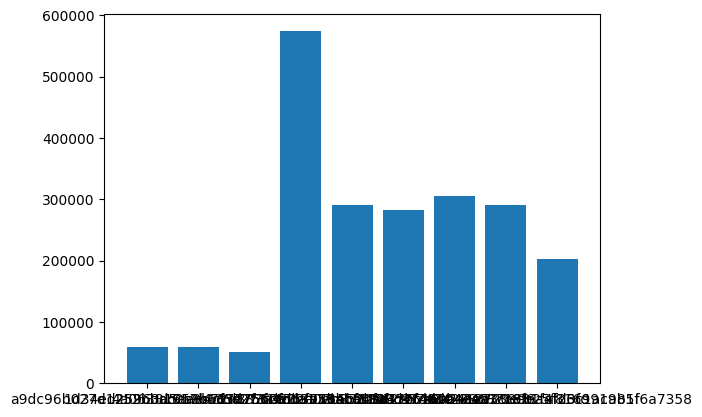

In [202]:
plt.bar(df12['customers'],df12['sum'])
plt.xlabel("sum")
plt.title('top 3 customers who spent most money in each year', fontsize=20, color='red')